In [15]:
import pandas as pd
import numpy as np

# carregar o dataset de clientes
clientes = pd.read_csv(r"C:\Users\natha\OneDrive\Área de Trabalho\Projeto - E-Commerce\olist_customers_dataset.csv")

# visualizar as primeiras linhas
print(clientes.head())


                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  


In [16]:
# verificar dimensões
print(clientes.shape) # linhas e colunas

(99441, 5)


In [17]:
# conferir tipos de dados
print(clientes.info())

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None


In [18]:
# estatísticas básicas
print(clientes.describe())

       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000


In [19]:
# limpeza de dados para valores nulos
print(clientes.isnull().sum())

clientes = clientes.dropna() 

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


In [20]:
# limpeza de dados para dados duplicados
print(clientes.duplicated().sum())
clientes = clientes.drop_duplicates()

0


In [21]:
# padronizar os textos (ex: nomes de cidades).
clientes['customer_city'] = clientes['customer_city'].str.lower().str.strip()

In [22]:
# Integração com outros datasets
# Juntando os dados de clientes com pedidos e itens

orders = pd.read_csv(r"C:\Users\natha\OneDrive\Área de Trabalho\Projeto - E-Commerce\olist_orders_dataset.csv")
items = pd.read_csv(r"C:\Users\natha\OneDrive\Área de Trabalho\Projeto - E-Commerce\olist_order_items_dataset.csv")

# Merge clientes ↔ pedidos
clientes_orders = pd.merge(clientes, orders, on="customer_id", how="inner")

# Merge pedidos ↔ itens
full_data = pd.merge(clientes_orders, items, on="order_id", how="inner")

In [23]:
# número de clientes por estado
clientes['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [24]:
# ticket médio
full_data['price'].mean()

np.float64(120.65373901464714)

In [25]:
full_data['product_id'].value_counts().head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64

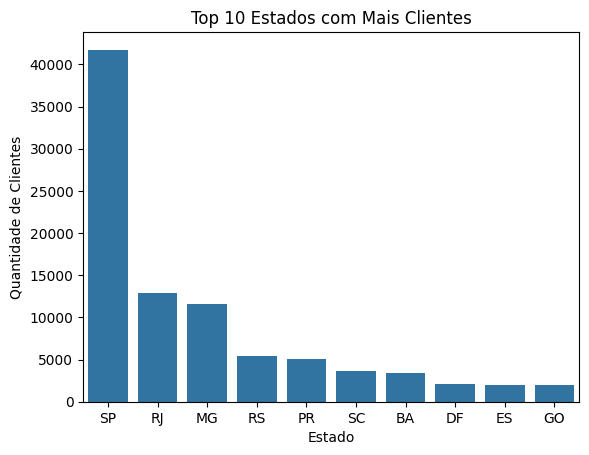

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Carregar dados reais
clientes = pd.read_csv(r"C:\Users\natha\OneDrive\Área de Trabalho\Projeto - E-Commerce\olist_customers_dataset.csv")

# Contar quantos clientes por estado
vendas_por_estado = clientes['customer_state'].value_counts().head(10)

# Criar DataFrame para o gráfico
dados = pd.DataFrame({
    "estado": vendas_por_estado.index,
    "quantidade": vendas_por_estado.values
})

# Gráfico com dados REAIS
sns.barplot(x="estado", y="quantidade", data=dados)
plt.title("Top 10 Estados com Mais Clientes")
plt.xlabel("Estado")
plt.ylabel("Quantidade de Clientes")
plt.show()